# Underfitting Model

by Niklas Vogel and Kevin Stupar

## Setup
This notebook creates an underfitting model and evaluates it.

Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
TODO

# Load the data and split it

In [2]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, plot_number_per_class, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  9043
Number of validation images:  2260
Number of testing images:  4845
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


E0000 00:00:1775906573.667425  130798 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775906573.667598  130947 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775906573.682563  130798 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

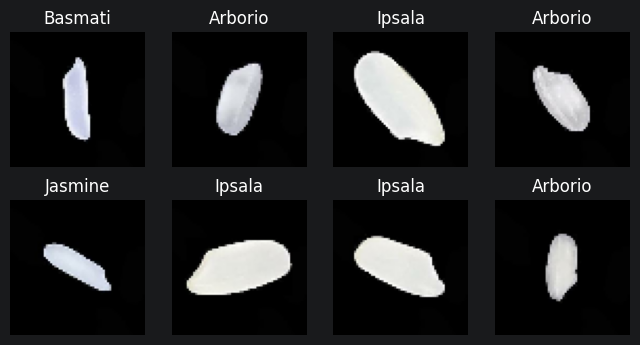

In [3]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 4000 images, except for Karacadag, which only has 150 images.
This should lead to a worse performance of this class.

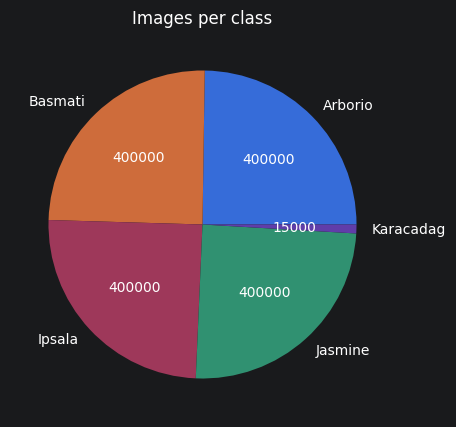

In [4]:
plot_number_per_class(all_images, label_names)

# Building the model

To obtain an underfitting model, the network is intentionally kept small by using only two convolutional layers followed by one dense output layer.

The two convolutional layers are responsible for extracting features from the input images. The first layer learns basic visual patterns such as edges and textures, while the second layer extracts slightly more abstract features.

After each convolutional layer, a MaxPooling operation is applied to reduce the spatial size of the feature maps while preserving the most dominant information. This downsampling reduces computational complexity and decreases the number of trainable parameters in subsequent layers.

The first MaxPooling layer reduces the image size moderately to retain sufficient information for further feature extraction. In contrast, the second MaxPooling layer performs a much stronger reduction, keeping only the most prominent features. After flattening, these compressed features are passed to the dense layer, which performs the final multi-class classification.

Because the model contains very few trainable parameters and limited depth, it lacks the capacity to learn complex patterns, which results in underfitting.

Why avoid stride>kernel-size: Strides larger than the kernel size should be avoided otherwise parts of the image would be skip, causing information loss during feature extraction.

In [5]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(2, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 2)      │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551 (2.15 KB)

 Trainable params: 551 (2.15 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Now we need to compile and train the model, which could take some time.

In [6]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_images, epochs=30, validation_data=validation_images)

Epoch 1/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6737 - loss: 0.9545 - val_accuracy: 0.8819 - val_loss: 0.4801
Epoch 2/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9233 - loss: 0.3320 - val_accuracy: 0.9584 - val_loss: 0.2215
Epoch 3/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9568 - loss: 0.1998 - val_accuracy: 0.9580 - val_loss: 0.1752
Epoch 4/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9617 - loss: 0.1551 - val_accuracy: 0.9624 - val_loss: 0.1463
Epoch 5/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1304 - val_accuracy: 0.9677 - val_loss: 0.1193
Epoch 6/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9661 - loss: 0.1220 - val_accuracy: 0.9642 - val_loss: 0.1242
Epoch 7/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9678 - loss: 0.1072 - val_accuracy: 0.9642 - val_loss: 0.1149
Epoch 8/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9663 - loss: 0.1083 - val_accuracy: 0.

# Evaluating the model

Using a few plots we can see, that the model is underfitting.
Note that the loss is on a log scale to be able to interpret the results better.

In [7]:
true, pred = calculate_predictions(model, test_images)

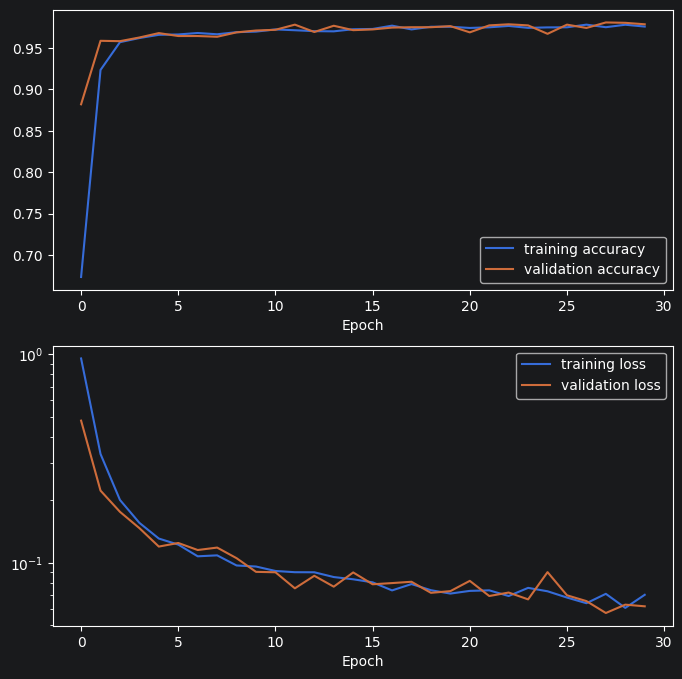

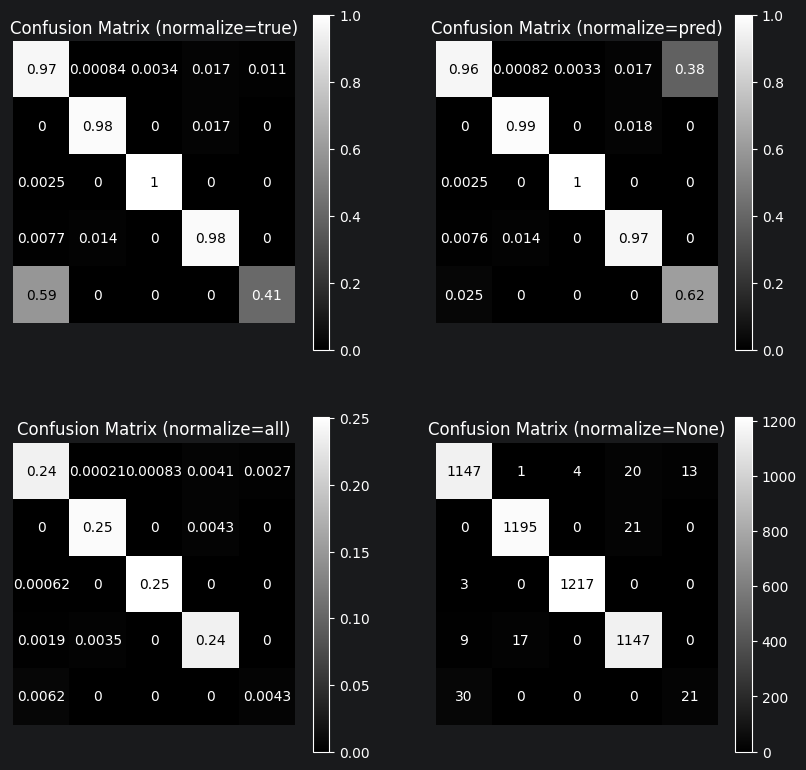

NameError: name 'black' is not defined

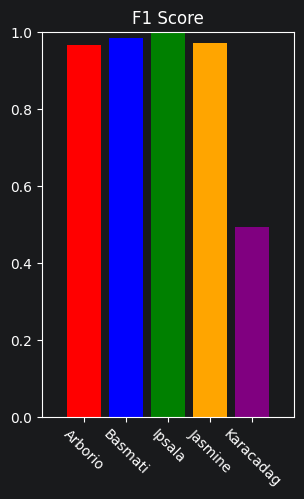

In [8]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion